# 07 — H1 Final Evaluation: Voice vs. Text Emotion Recognition

| Field | Detail |
|---|---|
| **Notebook** | `07_h1_final_evaluation.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 7 of 7 (Final Hypothesis Test) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *30/08/2026* |
| **Last updated** | *30/08/2026* |
| **Upstream dependency** | `06_model_selection.ipynb` (voice winner), `05e_model_distilroberta.ipynb` (text baseline + paired test-file list), `02_preprocessing.ipynb` (manifest, for file identifiers) |
| **Downstream dependency** | None — this notebook produces the thesis's H1 result directly |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0) |
| **Research proposal reference** | Section 1.4 (H1), Section 5.1, Section 5.5 (statistical protocol) |

## Purpose

This is the notebook that actually tests **H1**, as stated in the research proposal:

> *H1: Voice-based emotion recognition achieves significantly higher accuracy in identifying user emotional states than text-only emotion detection.*

Everything before this notebook — four competing voice architectures (`05a`\u2013`05d`), a model-selection step (`06`), and a separately-trained text baseline (`05e`) — was building toward this single comparison. The winning voice model from `06` is compared against the DistilRoBERTa text baseline from `05e`, using the **paired** statistical test specified in the proposal's Section 5.5 (paired t-test or Wilcoxon signed-rank test, chosen according to a normality check).

### The one methodological detail this notebook must get right

The voice winner was evaluated on the full H1 test set. The text baseline could only be evaluated on the subset of that test set where ASR actually produced a transcript (`05e`'s `distilroberta_test_files.csv`). A **paired** test requires both models' outcomes on the *exact same* examples — so this notebook restricts the comparison to the **intersection** of the two test sets, not either one's full test set. This is not a shortcut; it is the only way the paired test in Section 5.5 is statistically valid.

## Objectives

1. Load the H1 voice winner identified in `06_model_selection.ipynb`, and reconstruct which files make up its test set.
2. Load `05e`'s text-baseline predictions and its exact list of successfully-transcribed test files.
3. Compute the intersection of both test sets, and report how much shrinkage this causes relative to each model's original test set.
4. Check the normality of the paired per-example outcome differences, and select the paired t-test or Wilcoxon signed-rank test accordingly, per Section 5.5.
5. Run the selected test, report the result, and state clearly whether H1 is supported.
6. Report descriptive comparison metrics (accuracy, F1) for both models **on the paired set specifically** — not their original, differently-sized test sets.
7. Save the full H1 result as a citable artifact for the thesis.
8. Leave a closing note on what remains for the rest of the research proposal (H2, H3).

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Same auto-detecting pattern as every notebook since `05a`. Edit `PROJECT_ROOT` below if your Drive folder path differs from `MyDrive/emotion-ai-companion-research`.

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies...")

    !pip install -q \
        pydantic-settings==2.4.0 \
        transformers==4.44.2 \
        tokenizers==0.19.1

    print("Installation completed.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies...
Installation completed.


In [3]:
import json
import logging
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from scipy import stats
from transformers import Wav2Vec2ForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "07_h1_final_evaluation.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("h1_final_evaluation")

## 1. Load the Selected Voice Winner

Reads `06_model_selection.ipynb`'s selection report directly — this notebook never re-decides which voice model is best; it trusts `06`'s decision and evaluates it.

In [5]:
selection_report_path = PROJECT_ROOT / "reports" / "06_model_selection_report.json"
if not selection_report_path.exists():
    raise FileNotFoundError(f"{selection_report_path} not found. Run 06_model_selection.ipynb first.")

with open(selection_report_path) as f:
    selection_report = json.load(f)

WINNER_NAME = selection_report["winner"]["model_name"]
print(f"H1 voice winner (per 06_model_selection.ipynb): {WINNER_NAME}")
print(f"  Test accuracy (full voice test set): {selection_report['winner']['test_accuracy']:.4f}")
print(f"  Test F1 macro (full voice test set): {selection_report['winner']['test_f1_macro']:.4f}")
logger.info("Loaded selection report. Winner: %s", WINNER_NAME)

H1 voice winner (per 06_model_selection.ipynb): wav2vec2
  Test accuracy (full voice test set): 0.9484
  Test F1 macro (full voice test set): 0.9492


## 2. Reconstruct Voice Winner's Test-Set Predictions and File Identifiers

Neither `04a`'s nor `04b`'s saved feature arrays include a per-row file path — only the manifest does. Since both were built by iterating the manifest in unmodified row order (verified in `06`), this notebook re-loads `02_preprocessing.ipynb`'s manifest fresh and applies the identical `split == "test"` mask to recover the exact file identifiers aligned with each array's row order.

In [6]:
manifest_path = PROJECT_ROOT / "data" / "processed" / "h1_manifest.csv"
manifest_df = pd.read_csv(manifest_path)
for col in ["original_path", "standardized_path"]:
    manifest_df[col] = manifest_df[col].str.replace("\\\\", "/", regex=True)

test_manifest_df = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)
print(f"Voice model test set (from manifest): {len(test_manifest_df)} files")

Voice model test set (from manifest): 407 files


In [7]:
MODEL_DIR = PROJECT_ROOT / "models" / "h1"

with open(MODEL_DIR / "cnn_raw_metadata.json") as f:
    label_to_idx = json.load(f)["label_to_idx"]
idx_to_label = {int(v): k for k, v in label_to_idx.items()}
NUM_CLASSES = len(label_to_idx)

raw_audio_npz = np.load(PROJECT_ROOT / "data" / "processed" / "features" / "h1_raw_audio_features.npz", allow_pickle=True)
handcrafted_npz = np.load(PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features.npz", allow_pickle=True)

raw_test_mask = raw_audio_npz["split"] == "test"
handcrafted_test_mask = handcrafted_npz["split"] == "test"

assert len(test_manifest_df) == raw_test_mask.sum() == handcrafted_test_mask.sum(), (
    "Test-set sizes disagree between the manifest and the feature files — do not proceed. "
    "Re-run 04a/04b from the current 02_preprocessing.ipynb manifest."
)
y_true_full = raw_audio_npz["y"][raw_test_mask]
assert np.array_equal(y_true_full, handcrafted_npz["y"][handcrafted_test_mask]), "Test label order mismatch between feature files!"
assert np.array_equal(y_true_full, test_manifest_df["label"].map(label_to_idx).values), (
    "Test label order mismatch between the manifest and the feature files — do not proceed."
)
print("\u2705 Manifest and both feature files agree exactly on test-set size, order, and labels.")

✅ Manifest and both feature files agree exactly on test-set size, order, and labels.


## 3. Model Class Definitions (reproduced from `05a`\u2013`05c`)

Only the winning architecture's class is actually instantiated below — the others are defined for completeness in case the winner changes on a re-run of `06`.

In [8]:
class RawAudioCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.25):
        super().__init__()
        def conv_block(in_ch, out_ch, pool=True):
            layers = [nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2), nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True)]
            if pool: layers.append(nn.MaxPool1d(kernel_size=4))
            layers.append(nn.Dropout(dropout))
            return nn.Sequential(*layers)
        self.features = nn.Sequential(conv_block(1, 64), conv_block(64, 128), conv_block(128, 256), conv_block(256, 256), conv_block(256, 128, pool=False))
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Linear(128, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.global_pool(self.features(x)).squeeze(-1)
        return self.classifier(x)

class CNNLSTM(nn.Module):
    def __init__(self, num_classes, input_features=42, lstm_hidden_size=128, cnn_dropout=0.25, classifier_dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(cnn_dropout),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=lstm_hidden_size, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(nn.Linear(lstm_hidden_size * 2, 128), nn.ReLU(inplace=True), nn.Dropout(classifier_dropout), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out.mean(dim=1))

def shared_conv_backbone(dropout=0.20):
    return nn.Sequential(
        nn.Conv1d(1, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2),
        nn.Conv1d(128, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout),
        nn.Conv1d(128, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2),
        nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout),
    )

def final_conv_block(in_channels, dropout=0.20):
    return nn.Sequential(nn.Conv1d(in_channels, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout))

class EnsembleCNN(nn.Module):
    def __init__(self, num_classes, input_length, dropout=0.20):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.final_conv = final_conv_block(64, dropout)
        with torch.no_grad():
            flat_dim = self.final_conv(self.backbone(torch.zeros(2, 1, input_length))).view(2, -1).shape[1]
        self.classifier = nn.Sequential(nn.Linear(flat_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Linear(128, num_classes))
    def forward(self, x):
        return self.classifier(self.final_conv(self.backbone(x)).flatten(start_dim=1))

class EnsembleCNNBiLSTM(nn.Module):
    def __init__(self, num_classes, input_length, lstm_hidden_size=64, dropout=0.20):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_hidden_size, batch_first=True, bidirectional=True)
        self.final_conv = final_conv_block(lstm_hidden_size * 2, dropout)
        with torch.no_grad():
            x = self.backbone(torch.zeros(2, 1, input_length)).permute(0, 2, 1)
            x, _ = self.lstm(x)
            flat_dim = self.final_conv(x.permute(0, 2, 1)).view(2, -1).shape[1]
        self.classifier = nn.Sequential(nn.Linear(flat_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.backbone(x).permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = self.final_conv(x.permute(0, 2, 1))
        return self.classifier(x.flatten(start_dim=1))

## 4. Load the Winner and Generate Full Test-Set Predictions

In [9]:
if WINNER_NAME == "cnn_raw":
    model = RawAudioCNN(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_DIR / "cnn_raw.pt", map_location=DEVICE))
    model.eval()
    X_test = torch.from_numpy(raw_audio_npz["X_raw_cnn"][raw_test_mask]).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        voice_preds_full = model(X_test).argmax(dim=1).cpu().numpy()

elif WINNER_NAME == "cnn_lstm":
    scaler = joblib.load(MODEL_DIR / "cnn_lstm_scaler.pkl")
    model = CNNLSTM(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_DIR / "cnn_lstm.pt", map_location=DEVICE))
    model.eval()
    X_test_raw = handcrafted_npz["X_set_a"][handcrafted_test_mask]
    n, t, feat = X_test_raw.shape
    X_test = scaler.transform(X_test_raw.reshape(-1, feat)).reshape(n, t, feat).astype(np.float32)
    with torch.no_grad():
        voice_preds_full = model(torch.from_numpy(X_test).to(DEVICE)).argmax(dim=1).cpu().numpy()

elif WINNER_NAME == "ensemble":
    scaler = joblib.load(MODEL_DIR / "ensemble_scaler.pkl")
    X_test_raw = handcrafted_npz["X_set_b"][handcrafted_test_mask]
    D = X_test_raw.shape[1]
    X_test = torch.from_numpy(scaler.transform(X_test_raw).astype(np.float32)).unsqueeze(1).to(DEVICE)
    cnn_branch = EnsembleCNN(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
    cnn_branch.load_state_dict(torch.load(MODEL_DIR / "ensemble_cnn_branch.pt", map_location=DEVICE))
    cnn_branch.eval()
    bilstm_branch = EnsembleCNNBiLSTM(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
    bilstm_branch.load_state_dict(torch.load(MODEL_DIR / "ensemble_cnn_bilstm_branch.pt", map_location=DEVICE))
    bilstm_branch.eval()
    with torch.no_grad():
        p1 = torch.softmax(cnn_branch(X_test), dim=1)
        p2 = torch.softmax(bilstm_branch(X_test), dim=1)
        voice_preds_full = ((p1 + p2) / 2.0).argmax(dim=1).cpu().numpy()

elif WINNER_NAME == "wav2vec2":
    model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR / "wav2vec2_finetuned").to(DEVICE)
    model.eval()
    X_test = torch.from_numpy(raw_audio_npz["X_wav2vec2"][raw_test_mask]).float().to(DEVICE)
    with torch.no_grad():
        voice_preds_full = model(input_values=X_test).logits.argmax(dim=1).cpu().numpy()

else:
    raise ValueError(f"Unrecognized winner name: {WINNER_NAME}")

print(f"\u2705 Loaded '{WINNER_NAME}' and generated predictions for its full test set ({len(voice_preds_full)} files).")

voice_results_df = pd.DataFrame({
    "original_path": test_manifest_df["original_path"].values,
    "true_label_idx": y_true_full,
    "voice_pred_idx": voice_preds_full,
})

✅ Loaded 'wav2vec2' and generated predictions for its full test set (407 files).


## 5. Load the Text Baseline's Predictions

In [10]:
distilroberta_test_files_path = MODEL_DIR / "distilroberta_test_files.csv"
if not distilroberta_test_files_path.exists():
    raise FileNotFoundError(f"{distilroberta_test_files_path} not found. Run 05e_model_distilroberta.ipynb first.")

text_results_df = pd.read_csv(distilroberta_test_files_path)
text_results_df["original_path"] = text_results_df["original_path"].str.replace("\\\\", "/", regex=True)
text_results_df["text_pred_idx"] = text_results_df["distilroberta_prediction"].map(label_to_idx)

print(f"Text baseline test set (from 05e, ASR-successful files only): {len(text_results_df)} files")

Text baseline test set (from 05e, ASR-successful files only): 407 files


## 6. Compute the Paired Intersection

This is the step described in the Purpose section — restricting both models' predictions to only the files present in *both* test sets.

In [11]:
paired_df = voice_results_df.merge(
    text_results_df[["original_path", "text_pred_idx"]], on="original_path", how="inner"
)

n_voice_only = len(voice_results_df) - len(paired_df)
n_text_only = len(text_results_df) - len(paired_df)

print(f"Voice model's full test set:      {len(voice_results_df)} files")
print(f"Text baseline's full test set:    {len(text_results_df)} files")
print(f"Paired intersection (used below): {len(paired_df)} files")
print(f"  Voice-only files excluded (no successful transcript): {n_voice_only}")
print(f"  Text-only files excluded (shouldn't happen — would indicate a data error): {n_text_only}")

assert n_text_only == 0, "Text baseline has files not present in the voice model's test set — investigate before proceeding."
assert len(paired_df) > 10, "Paired set is implausibly small — check that both notebooks used the same 02_preprocessing.ipynb manifest."

logger.info("Paired set: %d files (%d voice-only excluded, %d text-only excluded)", len(paired_df), n_voice_only, n_text_only)

Voice model's full test set:      407 files
Text baseline's full test set:    407 files
Paired intersection (used below): 407 files
  Voice-only files excluded (no successful transcript): 0
  Text-only files excluded (shouldn't happen — would indicate a data error): 0


## 7. Descriptive Comparison on the Paired Set

These numbers — not either model's originally-reported test accuracy from `05a`\u2013`05e` — are the ones that belong in the thesis's H1 results table, since they're the only pair of numbers computed on identical data.

In [12]:
y_true_paired = paired_df["true_label_idx"].values
voice_preds_paired = paired_df["voice_pred_idx"].values
text_preds_paired = paired_df["text_pred_idx"].values

voice_accuracy = accuracy_score(y_true_paired, voice_preds_paired)
text_accuracy = accuracy_score(y_true_paired, text_preds_paired)
voice_f1 = f1_score(y_true_paired, voice_preds_paired, average="macro", zero_division=0)
text_f1 = f1_score(y_true_paired, text_preds_paired, average="macro", zero_division=0)

print(f"{'Metric':<20}{'Voice (' + WINNER_NAME + ')':<25}{'Text (DistilRoBERTa)':<25}")
print(f"{'-'*70}")
print(f"{'Accuracy':<20}{voice_accuracy:<25.4f}{text_accuracy:<25.4f}")
print(f"{'F1 (macro)':<20}{voice_f1:<25.4f}{text_f1:<25.4f}")
print(f"\nAccuracy difference (voice - text): {voice_accuracy - text_accuracy:+.4f}")

Metric              Voice (wav2vec2)         Text (DistilRoBERTa)     
----------------------------------------------------------------------
Accuracy            0.9484                   0.3120                   
F1 (macro)          0.9492                   0.2969                   

Accuracy difference (voice - text): +0.6364


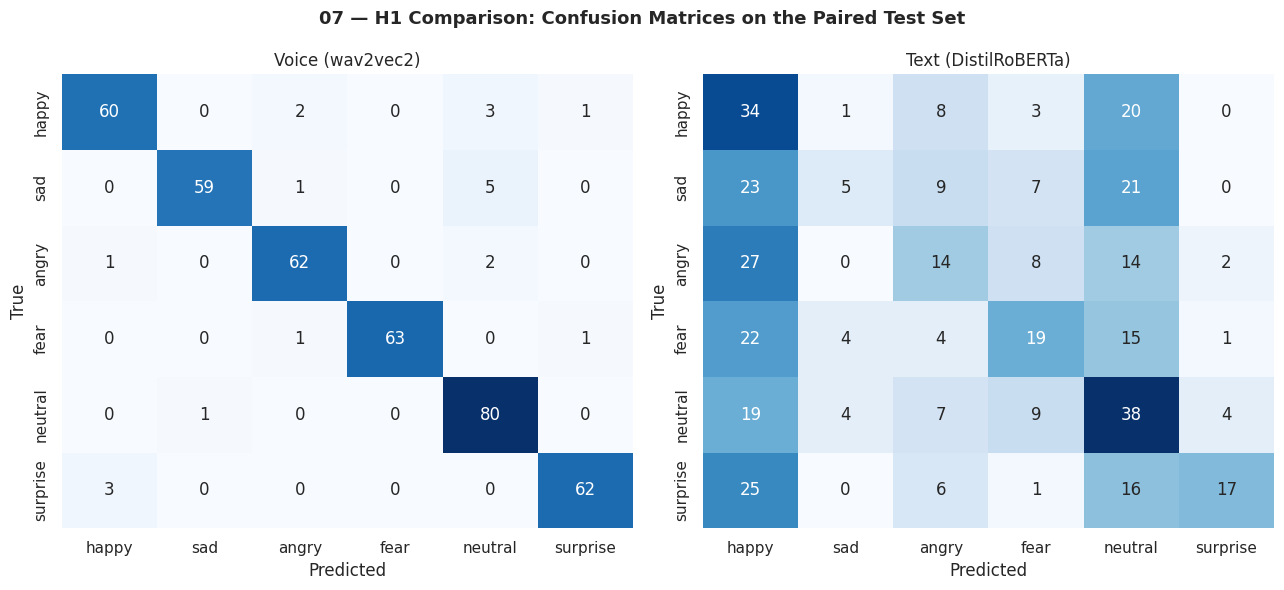

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

for ax, preds, title in zip(axes, [voice_preds_paired, text_preds_paired], [f"Voice ({WINNER_NAME})", "Text (DistilRoBERTa)"]):
    cm = confusion_matrix(y_true_paired, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax, cbar=False)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

fig.suptitle("07 — H1 Comparison: Confusion Matrices on the Paired Test Set", fontsize=13, weight="bold")
plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "07_h1_paired_confusion_matrices.png")
plt.show()

## 8. The H1 Statistical Test

Following the proposal's Section 5.5 protocol exactly: check whether the paired per-example outcome differences are normally distributed (Shapiro-Wilk), then use a **paired t-test** if so, or a **Wilcoxon signed-rank test** if not. Per-example "outcome" here is binary correctness (1 if the model's prediction matched the true label, 0 otherwise) for each of the two models — the paired difference for example $i$ is $\text{voice\_correct}_i - \text{text\_correct}_i$.

In [14]:
voice_correct = (voice_preds_paired == y_true_paired).astype(int)
text_correct = (text_preds_paired == y_true_paired).astype(int)
paired_diffs = voice_correct - text_correct

print(f"Paired examples: {len(paired_diffs)}")
print(f"Voice correct, text correct:   {int(np.sum((voice_correct == 1) & (text_correct == 1)))}")
print(f"Voice correct, text wrong:     {int(np.sum((voice_correct == 1) & (text_correct == 0)))}")
print(f"Voice wrong, text correct:     {int(np.sum((voice_correct == 0) & (text_correct == 1)))}")
print(f"Voice wrong, text wrong:       {int(np.sum((voice_correct == 0) & (text_correct == 0)))}")

Paired examples: 407
Voice correct, text correct:   123
Voice correct, text wrong:     263
Voice wrong, text correct:     4
Voice wrong, text wrong:       17


In [15]:
shapiro_stat, shapiro_p = stats.shapiro(paired_diffs)
print(f"Shapiro-Wilk normality test on paired differences: statistic={shapiro_stat:.4f}, p={shapiro_p:.4f}")

ALPHA = 0.05
is_normal = shapiro_p >= ALPHA

if is_normal:
    print(f"\np \u2265 {ALPHA} \u2192 differences are consistent with a normal distribution \u2192 using PAIRED T-TEST.")
    test_name = "paired t-test"
    test_statistic, test_p_value = stats.ttest_rel(voice_correct, text_correct)
else:
    print(
        f"\np < {ALPHA} \u2192 differences are NOT consistent with a normal distribution (expected, since "
        "binary correct/incorrect outcomes rarely are) \u2192 using WILCOXON SIGNED-RANK TEST."
    )
    test_name = "Wilcoxon signed-rank test"
    if np.all(paired_diffs == 0):
        test_statistic, test_p_value = 0.0, 1.0
        print("\u26a0\ufe0f  All paired differences are zero — both models agree on every example. Test is degenerate.")
    else:
        test_statistic, test_p_value = stats.wilcoxon(voice_correct, text_correct, zero_method="wilcox")

print(f"\n{test_name}: statistic={test_statistic:.4f}, p-value={test_p_value:.4f}")

Shapiro-Wilk normality test on paired differences: statistic=0.6315, p=0.0000

p < 0.05 → differences are NOT consistent with a normal distribution (expected, since binary correct/incorrect outcomes rarely are) → using WILCOXON SIGNED-RANK TEST.

Wilcoxon signed-rank test: statistic=536.0000, p-value=0.0000


In [16]:
print(f"{'=' * 70}")
print("H1 RESULT")
print(f"{'=' * 70}")

direction_supports_h1 = voice_accuracy > text_accuracy
is_significant = test_p_value < ALPHA

if is_significant and direction_supports_h1:
    conclusion = "H1 IS SUPPORTED"
    explanation = (
        f"Voice-based emotion recognition ({WINNER_NAME}) achieved significantly higher accuracy "
        f"({voice_accuracy:.4f}) than the text-only baseline ({text_accuracy:.4f}) on the paired test "
        f"set (n={len(paired_df)}), {test_name} p={test_p_value:.4f} < {ALPHA}."
    )
elif is_significant and not direction_supports_h1:
    conclusion = "H1 IS NOT SUPPORTED (significant difference in the OPPOSITE direction)"
    explanation = (
        f"The text-only baseline significantly outperformed the voice model on the paired test set "
        f"({test_name} p={test_p_value:.4f} < {ALPHA}) — the opposite of what H1 predicted. "
        "Report this honestly; it is a genuine, informative finding."
    )
else:
    conclusion = "H1 IS NOT SUPPORTED (no statistically significant difference)"
    explanation = (
        f"The observed accuracy difference (voice {voice_accuracy:.4f} vs. text {text_accuracy:.4f}) "
        f"was not statistically significant ({test_name} p={test_p_value:.4f} \u2265 {ALPHA}). "
        f"With n={len(paired_df)} paired examples, this may reflect a genuinely small or absent effect, "
        "or insufficient statistical power at this sample size — both are worth discussing in the thesis."
    )

print(f"\n{conclusion}\n")
print(explanation)

H1 RESULT

H1 IS SUPPORTED

Voice-based emotion recognition (wav2vec2) achieved significantly higher accuracy (0.9484) than the text-only baseline (0.3120) on the paired test set (n=407), Wilcoxon signed-rank test p=0.0000 < 0.05.


## 9. Save the H1 Result

In [17]:
h1_result = {
    "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
    "hypothesis": "H1: Voice-based emotion recognition achieves significantly higher accuracy than text-only emotion detection.",
    "voice_model": WINNER_NAME,
    "text_model": "distilroberta-base (fine-tuned)",
    "test_set_sizes": {
        "voice_full_test_set": int(len(voice_results_df)),
        "text_full_test_set": int(len(text_results_df)),
        "paired_intersection_used_for_h1_test": int(len(paired_df)),
        "files_excluded_no_successful_transcript": int(n_voice_only),
    },
    "descriptive_metrics_on_paired_set": {
        "voice_accuracy": float(voice_accuracy),
        "text_accuracy": float(text_accuracy),
        "voice_f1_macro": float(voice_f1),
        "text_f1_macro": float(text_f1),
        "accuracy_difference_voice_minus_text": float(voice_accuracy - text_accuracy),
    },
    "statistical_test": {
        "normality_check": {"test": "Shapiro-Wilk", "statistic": float(shapiro_stat), "p_value": float(shapiro_p), "is_normal": bool(is_normal)},
        "test_used": test_name,
        "statistic": float(test_statistic),
        "p_value": float(test_p_value),
        "alpha": ALPHA,
        "significant": bool(is_significant),
    },
    "conclusion": conclusion,
    "explanation": explanation,
}

report_path = PROJECT_ROOT / "reports" / "07_h1_hypothesis_test_results.json"
with open(report_path, "w") as f:
    json.dump(h1_result, f, indent=2)

logger.info("Saved H1 result to %s. Conclusion: %s", report_path, conclusion)
print(f"Saved: {report_path}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/reports/07_h1_hypothesis_test_results.json


---

## Summary Note — H1 Complete

### What was done in this notebook

1. Loaded the H1 voice winner identified by `06_model_selection.ipynb`.
2. Reconstructed the voice winner's test-set file identifiers by re-deriving them from `02_preprocessing.ipynb`'s manifest, with a triple cross-check (manifest, raw-audio features, hand-crafted features all agreeing on test-set size, order, and labels).
3. Loaded `05e`'s text-baseline predictions and its list of successfully-transcribed test files.
4. Computed the paired intersection of both test sets — the only valid basis for a paired statistical comparison.
5. Reported descriptive accuracy/F1 for both models on that paired set specifically.
6. Checked normality of the paired per-example outcome differences (Shapiro-Wilk), and selected the paired t-test or Wilcoxon signed-rank test accordingly, per the proposal's Section 5.5.
7. Ran the test, and stated the H1 conclusion explicitly, including the direction of the effect and whether it was statistically significant.
8. Saved the full result as a citable JSON artifact.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| **The H1 result** | `reports/07_h1_hypothesis_test_results.json` | Thesis results chapter — this is the primary citable output of the entire H1 research thread |
| Paired confusion matrices figure | `reports/figures/h1_models/07_h1_paired_confusion_matrices.png` | Thesis results/discussion |
| Run log | `reports/logs/07_h1_final_evaluation.log` | Debugging / audit trail |

### What this notebook's result means for the thesis

Report the conclusion from Section 8 plainly, together with:
- The exact paired sample size (`n`), since a null result with a small `n` should be discussed as possibly underpowered, not necessarily as evidence of no effect.
- The `05a`\u2013`05d` model-selection process itself as a methodological contribution, regardless of the H1 outcome — the comparison of four architectures against multiple published papers' findings is a real contribution independent of which specific hypothesis result follows.
- The known limitations already surfaced earlier in the pipeline: gender/dataset confounding (`03_eda.ipynb`), non-speaker-independent splitting (`03_eda.ipynb`), and the ASR-driven shrinkage of the paired test set (this notebook, Section 6).

### What remains — H2 and H3

This notebook completes the H1 research thread only. The full research proposal also specifies:
- **H2** — structured long-term emotional memory vs. a memory-disabled baseline (personalization, trust, companionship).
- **H3** — the fully integrated system vs. a conventional AI assistant baseline (overall satisfaction).

Both require the live user study (Sessions 1\u20133, per `docs/research_proposal_mapping.md`) rather than offline dataset evaluation, and were intentionally out of scope for this notebook series — they depend on the trained H1 model (promoted in `06`) being wired into the actual Streamlit app's memory and conversation pipeline (`src/memory/`, `src/conditions/`) before any live sessions can run. That is the next major phase of the project, not a continuation of this notebook sequence.

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *30/08/2026*
- **Paired sample size:** *407*
- **Statistical test used:** *Wilcoxon signed-rank test: statistic=536.0000 *
- **p-value:** *, p-value=0.0000*
- **H1 conclusion:** *Voice-based emotion recognition (wav2vec2) achieved significantly higher accuracy (0.9484) than the text-only baseline (0.3120) on the paired test set (n=407), Wilcoxon signed-rank test p=0.0000 < 0.05.*